# <span style="color:black; font-weight:bold;">Cross-modal alignment human hepatocellular carcinoma Tutorial</span>
+ <span style="color:black; font-weight:bold;">Creator</span>: Bingjie Dai (17516970902@163.com)
+ <span style="color:black; font-weight:bold;">Date of Creation</span>: 8.23.2026
+ <span style="color:black; font-weight:bold;">Date of Last Modification</span>: 8.23.2026
+ <span style="color:black; font-weight:bold;">Download</span>: The in-house multi-modal data will be made public after the article is published.
In this tutorial we apply MAPS to align Xenium and CODEX to HE dataset. Then, we used the aligned coordinates to obtain multiple omics and HE features for the paired cells of the same cell.

<span style="color:black; font-weight:bold;">The dataset have:</span>   
+ <span style="color:black; font-weight:bold;">Xenium(ST)</span>: 403,588 cells   
+ <span style="color:black; font-weight:bold;">CODEX</span>: 403,563 cells   
+ <span style="color:black; font-weight:bold;">HE</span>: 276,908 cells 

In [1]:
from MAPS.align import Multi_slices_rigid_alignment
from MAPS.utils import set_seed,create_new_color_dict,plot_aligned_adata_on_if
import scanpy as sc
import pandas as pd
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(7)

## <span style="color:black; font-weight:bold;">Loading Cross-modal human hepatocellular carcinoma data (Xenium, CODEX and HE)</span>
+ To ensure the accuracy of the scaling factor, we recommend using the HE slice as the target_adata for learning the scaling factor.

In [4]:
adata1=sc.read_h5ad('/home/dbj/LPcross/Data/zhikang/ID110100/ID1_xenium.h5ad')
adata1.obs['batch']='xenium'

adata2=sc.read_h5ad('/home/dbj/LPcross/Data/zhikang/ID110100/ID1_protein.h5ad')
adata2.obs['batch']='CODEX'

adata3=sc.read_h5ad('/home/dbj/LPcross/Data/zhikang/ID110100/ID1_HE.h5ad')
adata3.obs['batch']='HE'

## <span style="color:black; font-weight:bold;">Spatial mapping of the human hepatocellular carcinoma 3 modal before alignment</span>

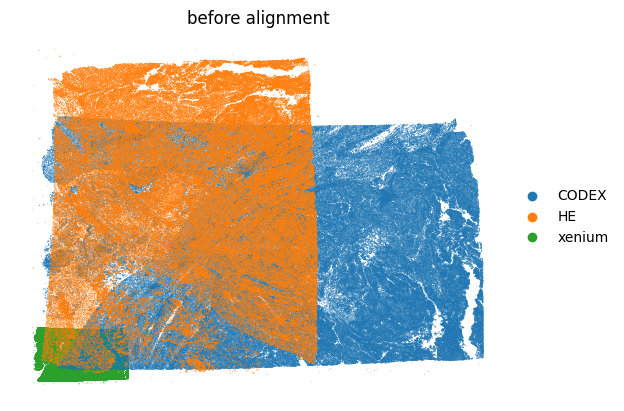

In [5]:
adata=sc.concat([adata1,adata2,adata3],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color='batch',size=1,title='before alignment',frameon=False)

## <span style="color:black; font-weight:bold;">Reference align using MAPS for multi-slices</span> 
### <span style="color:black; font-weight:bold;">Training parameters</span> 
+ epochs: Training ephchs  
+ device: Training device  
+ sample_size: The number of samples used for alignment  
+ enable_scale: Whether to learn the scaling factor?  
+ mode: 'reference' The slices are aligned to the reference target  
+ ref_idx: Reference target, the other slices are aligned to the target slice

### <span style="color:black; font-weight:bold;">Output</span>   
+ reference_list: A list of slices after reference align 

### <span style="color:black; font-weight:bold;">We set HE as the ref_idx</span>  

In [6]:
adata_list=[adata1,adata2,adata3]
reference_adata_list = Multi_slices_rigid_alignment(adata_list, mode='reference', ref_idx=2,epochs=5000, sample_size=30000, enable_scale=True, device=device)


--- Aligning Slice 1 to Reference (Slice 3) ---
Scanning angles to find best starting angle...


Global Align: 100%|████████████████████████████████| 5000/5000 [03:21<00:00, 24.83it/s, Loss=86.04, Scale=4.130, Rot=89.35°, Trans=(10453.4, 19761.7)]


Peak GPU memory usage: 10.936 GB
Scale factor: 4.130, Rotation angle: 89.42°, Translation (x, y): (10453.77, 19760.17)

--- Aligning Slice 2 to Reference (Slice 3) ---
Scanning angles to find best starting angle...


Global Align: 100%|████████████████████████████████| 5000/5000 [03:20<00:00, 24.88it/s, Loss=86.61, Scale=0.878, Rot=89.36°, Trans=(-10004.2, 6676.6)]


Peak GPU memory usage: 10.936 GB
Scale factor: 0.878, Rotation angle: 89.36°, Translation (x, y): (-10003.54, 6676.43)

--- Slice 3 is the reference, skipping ---

--- All slices have been aligned! ---


## <span style="color:black; font-weight:bold;">2D spatial mapping of the reference alignment result for human hepatocellular carcinoma 3 modal</span>

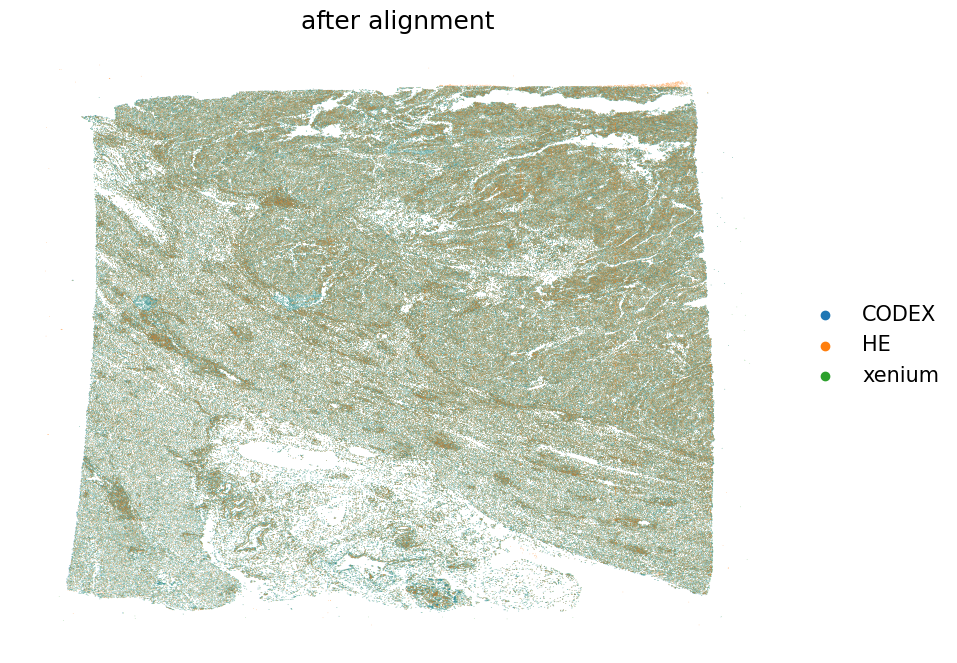

In [8]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (8,7)
plt.rcParams['font.size'] = 15

adata=sc.concat(reference_adata_list,join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color=['batch'],title='after alignment',size=0.7,alpha=0.7,frameon=False)

In [9]:
adata1.obsm['spatial']=reference_adata_list[0].obsm['spatial']
adata2.obsm['spatial']=reference_adata_list[1].obsm['spatial']

## <span style="color:black; font-weight:bold;">Spatial co-localization of Xenium and HE</span> 

(<Figure size 1200x1050 with 1 Axes>, <Axes: >)

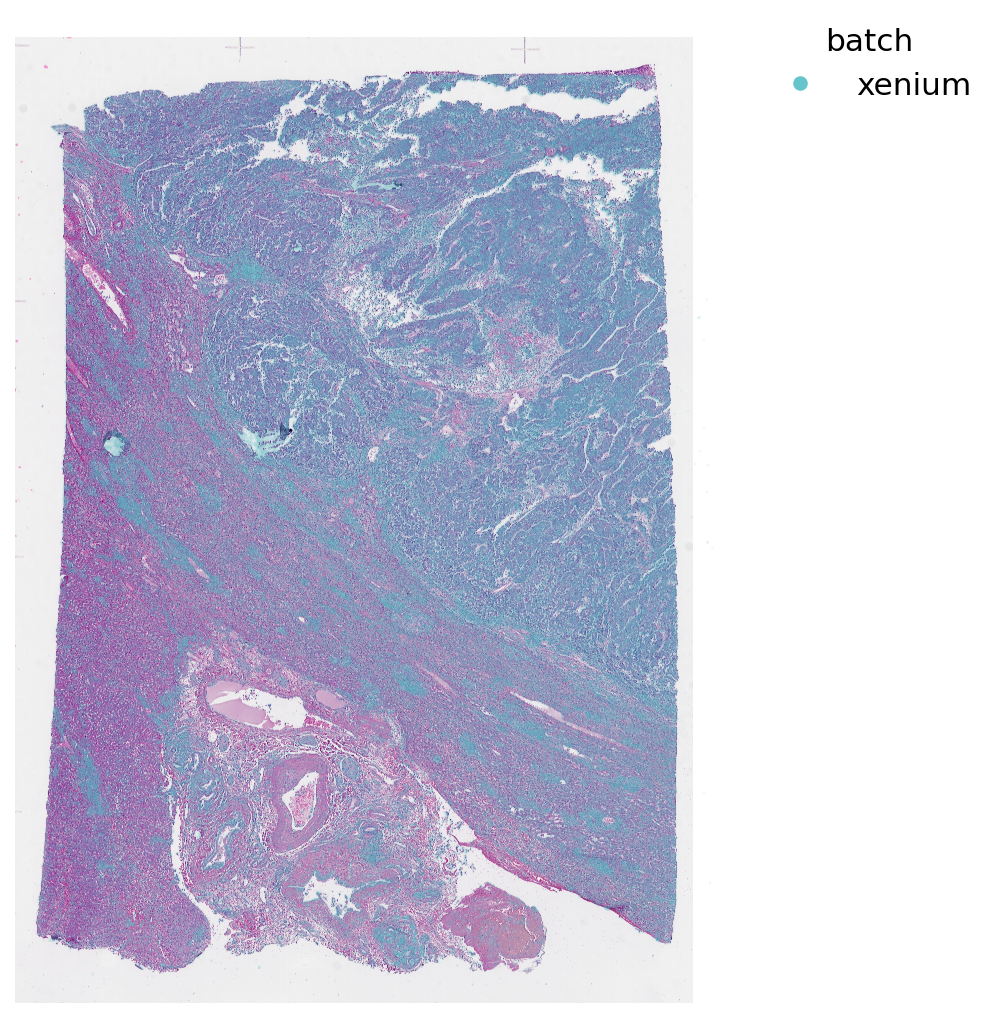

In [10]:
img_path = '/home/dbj/LPcross/Data/zhikang/ID110100/ID0041831-Xenium-5K-he-sample1-id1.ome.tif'
color_dict=create_new_color_dict(adata1,cat_key='batch')

plot_aligned_adata_on_if(image_path=img_path, 
                         adata=adata1,
                         color_by='batch',
                         is_gene=False,
                         s=0.01,
                         palette=color_dict,
                         figsize=(8,7),
                         dpi=150,
                         #save_path='/home/dbj/LPcross/Data/result/HE/zhikang/clusterHEDPI600test.png'
                        )

## <span style="color:black; font-weight:bold;">Spatial co-localization of CODEX and HE</span> 

(<Figure size 1200x1050 with 1 Axes>, <Axes: >)

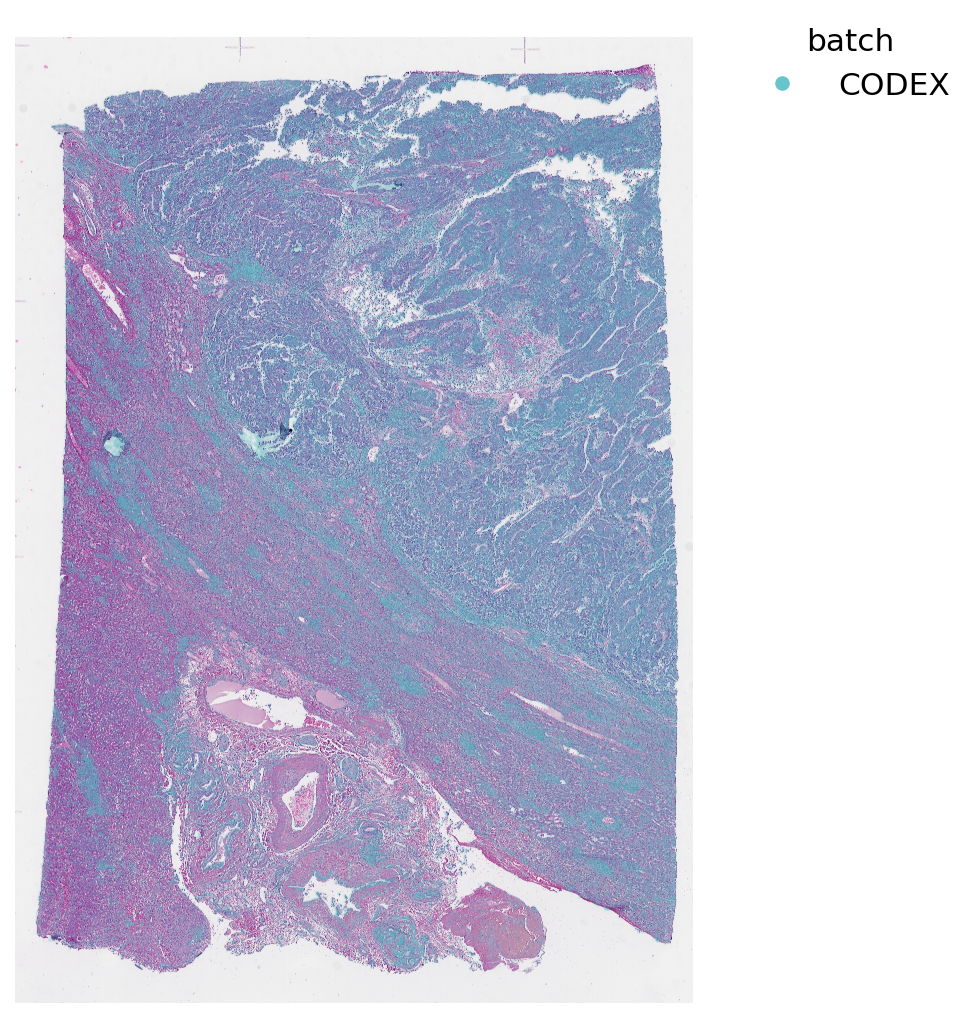

In [11]:
img_path = '/home/dbj/LPcross/Data/zhikang/ID110100/ID0041831-Xenium-5K-he-sample1-id1.ome.tif'
color_dict=create_new_color_dict(adata2,cat_key='batch')

plot_aligned_adata_on_if(image_path=img_path, 
                         adata=adata2,
                         color_by='batch',
                         is_gene=False,
                         s=0.01,
                         palette=color_dict,
                         figsize=(8,7),
                         dpi=150,
                         #save_path='/home/dbj/LPcross/Data/result/HE/zhikang/clusterHEDPI600test.png'
                        )